# IBM RH Análise de Atrito & Performance de Funcionários

## Análise Exploratória e Tratamentos de Dados

In [43]:
#Bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

import joblib
import os

#Arquivos auxiliares src
from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_TRATADOS, MODELO_FINAL
from src.models_rus import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
    RANDOM_STATE
)
from src.graficos import plot_comparar_metricas_modelos, plot_coeficientes
#Configurações
pd.set_option('display.max_columns', None)

#Skitlearing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
#dummy
from sklearn.dummy import DummyClassifier
#Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(palette = 'bright')


In [5]:
df= pd.read_parquet(DADOS_TRATADOS)
df.head()

,AnosComGerenteAtual,AnosDesdeAUltimaPromocao,AnosNaEmpresa,AnosNoCargoAtual,AreaDeFormacao,AvaliacaoDeDesempenho,Cargo,Departamento,Desligamento,DistanciaDeCasa,EnvolvimentoNoTrabalho,EquilibrioVidaTrabalho,Escolaridade,EstadoCivil,Genero,HoraExtra,Idade,NivelDeOpcoesDeAcoes,NivelDoCargo,NumeroDeEmpresasQueTrabalhou,PercentualDeAumentoSalarial,RendaMensal,SatisfacaoComAmbiente,SatisfacaoComOTrabalho,SatisfacaoComRelacionamentos,TaxaDiaria,TaxaHoraria,TaxaMensal,TotalDeAnosTrabalhados,TreinamentosNoAnoPassado,ViagemDeNegocios
0,5,0,6,4,Ciências Biológicas,3,Executivo de Vendas,Vendas,Sim,1,3,1,2,Solteiro(a),Feminino,Sim,41,0,2,8,11,5993,2,4,1,1102,94,19479,8,0,Viaja Raramente
1,7,1,10,7,Ciências Biológicas,4,Cientista de Pesquisa,Pesquisa e Desenvolvimento,Não,8,2,3,1,Casado(a),Masculino,Não,49,1,2,1,23,5130,3,2,4,279,61,24907,10,3,Viaja Frequentemente
2,0,0,0,0,Outros,3,Técnico de Laboratório,Pesquisa e Desenvolvimento,Sim,2,2,3,2,Solteiro(a),Masculino,Sim,37,0,1,6,15,2090,4,3,2,1373,92,2396,7,3,Viaja Raramente
3,0,3,8,7,Ciências Biológicas,3,Cientista de Pesquisa,Pesquisa e Desenvolvimento,Não,3,3,3,4,Casado(a),Feminino,Sim,33,0,1,1,11,2909,4,3,3,1392,56,23159,8,3,Viaja Frequentemente
4,2,2,2,2,Medicina,3,Técnico de Laboratório,Pesquisa e Desenvolvimento,Não,2,3,3,1,Casado(a),Masculino,Não,27,1,1,9,12,3468,1,2,4,591,40,16632,6,3,Viaja Raramente


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   AnosComGerenteAtual           1470 non-null   int8    
 1   AnosDesdeAUltimaPromocao      1470 non-null   int8    
 2   AnosNaEmpresa                 1470 non-null   int8    
 3   AnosNoCargoAtual              1470 non-null   int8    
 4   AreaDeFormacao                1470 non-null   str     
 5   AvaliacaoDeDesempenho         1470 non-null   int8    
 6   Cargo                         1470 non-null   str     
 7   Departamento                  1470 non-null   str     
 8   Desligamento                  1470 non-null   str     
 9   DistanciaDeCasa               1470 non-null   int8    
 10  EnvolvimentoNoTrabalho        1470 non-null   int8    
 11  EquilibrioVidaTrabalho        1470 non-null   int8    
 12  Escolaridade                  1470 non-null   int8    
 13 

In [7]:
df.describe()

,AnosComGerenteAtual,AnosDesdeAUltimaPromocao,AnosNaEmpresa,AnosNoCargoAtual,AvaliacaoDeDesempenho,DistanciaDeCasa,EnvolvimentoNoTrabalho,EquilibrioVidaTrabalho,Escolaridade,Idade,NivelDeOpcoesDeAcoes,NivelDoCargo,NumeroDeEmpresasQueTrabalhou,PercentualDeAumentoSalarial,RendaMensal,SatisfacaoComAmbiente,SatisfacaoComOTrabalho,SatisfacaoComRelacionamentos,TaxaDiaria,TaxaHoraria,TaxaMensal,TotalDeAnosTrabalhados,TreinamentosNoAnoPassado
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,4.123129,2.187755,7.008163,4.229252,3.153741,9.192517,2.729932,2.761224,2.912925,36.923810,0.793878,2.063946,2.693197,15.209524,6502.931293,2.721769,2.728571,2.712245,802.485714,65.891156,14313.103401,11.279592,2.799320
std,3.568136,3.222430,6.126525,3.623137,0.360824,8.106864,0.711561,0.706476,1.024165,9.135373,0.852077,1.106940,2.498009,3.659938,4707.956783,1.093082,1.102846,1.081209,403.509100,20.329428,7117.786044,7.780782,1.289271
min,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,1.000000,1.000000,1.000000,18.000000,0.000000,1.000000,0.000000,11.000000,1009.000000,1.000000,1.000000,1.000000,102.000000,30.000000,2094.000000,0.000000,0.000000
25%,2.000000,0.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,30.000000,0.000000,1.000000,1.000000,12.000000,2911.000000,2.000000,2.000000,2.000000,465.000000,48.000000,8047.000000,6.000000,2.000000
50%,3.000000,1.000000,5.000000,3.000000,3.000000,7.000000,3.000000,3.000000,3.000000,36.000000,1.000000,2.000000,2.000000,14.000000,4919.000000,3.000000,3.000000,3.000000,802.000000,66.000000,14235.500000,10.000000,3.000000
75%,7.000000,3.000000,9.000000,7.000000,3.000000,14.000000,3.000000,3.000000,4.000000,43.000000,1.000000,3.000000,4.000000,18.000000,8379.000000,4.000000,4.000000,4.000000,1157.000000,83.750000,20461.500000,15.000000,3.000000
max,17.000000,15.000000,40.000000,18.000000,4.000000,29.000000,4.000000,4.000000,5.000000,60.000000,3.000000,5.000000,9.000000,25.000000,19999.000000,4.000000,4.000000,4.000000,1499.000000,100.000000,26999.000000,40.000000,6.000000


In [8]:
df.describe(exclude='number')

,AreaDeFormacao,Cargo,Departamento,Desligamento,EstadoCivil,Genero,HoraExtra,ViagemDeNegocios
count,1470,1470,1470,1470,1470,1470,1470,1470
unique,6,9,3,2,3,2,2,3
top,Ciências Biológicas,Executivo de Vendas,Pesquisa e Desenvolvimento,Não,Casado(a),Masculino,Não,Viaja Raramente
freq,606,326,961,1233,673,882,1054,1043


In [9]:
coluna_alvo = ['Desligamento']
print(f"Coluna alvo: {coluna_alvo}")

#colunas ordenadas
colunas_categoricas_ordenadas = [
    'AvaliacaoDeDesempenho', 
    'EnvolvimentoNoTrabalho',
    'EquilibrioVidaTrabalho',
    'Escolaridade',
    'NivelDoCargo',
    'SatisfacaoComAmbiente',
    'SatisfacaoComOTrabalho',
    'SatisfacaoComRelacionamentos', 
    'ViagemDeNegocios',
    'NivelDeOpcoesDeAcoes'
    ]
print(f"Colunas categóricas ordenadas: {colunas_categoricas_ordenadas}")

#colunas categoricas
colunas_categoricas = df.select_dtypes(include='str').columns.tolist()
colunas_categoricas.remove(coluna_alvo[0])
colunas_categoricas = [col for col in colunas_categoricas if col not in colunas_categoricas_ordenadas]
print(f"Colunas categóricas: {colunas_categoricas}")

#colunas numéricas
colunas_numericas = [col for col in df.columns if col not in (colunas_categoricas_ordenadas+colunas_categoricas+coluna_alvo)]
print(f"Colunas numéricas: {colunas_numericas}")


Coluna alvo: ['Desligamento']
Colunas categóricas ordenadas: ['AvaliacaoDeDesempenho', 'EnvolvimentoNoTrabalho', 'EquilibrioVidaTrabalho', 'Escolaridade', 'NivelDoCargo', 'SatisfacaoComAmbiente', 'SatisfacaoComOTrabalho', 'SatisfacaoComRelacionamentos', 'ViagemDeNegocios', 'NivelDeOpcoesDeAcoes']
Colunas categóricas: ['AreaDeFormacao', 'Cargo', 'Departamento', 'EstadoCivil', 'Genero', 'HoraExtra']
Colunas numéricas: ['AnosComGerenteAtual', 'AnosDesdeAUltimaPromocao', 'AnosNaEmpresa', 'AnosNoCargoAtual', 'DistanciaDeCasa', 'Idade', 'NumeroDeEmpresasQueTrabalhou', 'PercentualDeAumentoSalarial', 'RendaMensal', 'TaxaDiaria', 'TaxaHoraria', 'TaxaMensal', 'TotalDeAnosTrabalhados', 'TreinamentosNoAnoPassado']


In [10]:
df[colunas_categoricas_ordenadas].head()

,AvaliacaoDeDesempenho,EnvolvimentoNoTrabalho,EquilibrioVidaTrabalho,Escolaridade,NivelDoCargo,SatisfacaoComAmbiente,SatisfacaoComOTrabalho,SatisfacaoComRelacionamentos,ViagemDeNegocios,NivelDeOpcoesDeAcoes
0,3,3,1,2,2,2,4,1,Viaja Raramente,0
1,4,2,3,1,2,3,2,4,Viaja Frequentemente,1
2,3,2,3,2,1,4,3,2,Viaja Raramente,0
3,3,3,3,4,1,4,3,3,Viaja Frequentemente,0
4,3,3,3,1,1,1,2,4,Viaja Raramente,1


In [11]:
df[colunas_categoricas].head()

,AreaDeFormacao,Cargo,Departamento,EstadoCivil,Genero,HoraExtra
0,Ciências Biológicas,Executivo de Vendas,Vendas,Solteiro(a),Feminino,Sim
1,Ciências Biológicas,Cientista de Pesquisa,Pesquisa e Desenvolvimento,Casado(a),Masculino,Não
2,Outros,Técnico de Laboratório,Pesquisa e Desenvolvimento,Solteiro(a),Masculino,Sim
3,Ciências Biológicas,Cientista de Pesquisa,Pesquisa e Desenvolvimento,Casado(a),Feminino,Sim
4,Medicina,Técnico de Laboratório,Pesquisa e Desenvolvimento,Casado(a),Masculino,Não


In [12]:
df[colunas_numericas].head()

,AnosComGerenteAtual,AnosDesdeAUltimaPromocao,AnosNaEmpresa,AnosNoCargoAtual,DistanciaDeCasa,Idade,NumeroDeEmpresasQueTrabalhou,PercentualDeAumentoSalarial,RendaMensal,TaxaDiaria,TaxaHoraria,TaxaMensal,TotalDeAnosTrabalhados,TreinamentosNoAnoPassado
0,5,0,6,4,1,41,8,11,5993,1102,94,19479,8,0
1,7,1,10,7,8,49,1,23,5130,279,61,24907,10,3
2,0,0,0,0,2,37,6,15,2090,1373,92,2396,7,3
3,0,3,8,7,3,33,1,11,2909,1392,56,23159,8,3
4,2,2,2,2,2,27,9,12,3468,591,40,16632,6,3


In [13]:
colunas_min_max = [
    'TaxaDiaria',
    'TaxaHoraria',
    'TaxaMensal'
]

colunas_standard_scaler = [
    'Idade'
]

colunas_power = [coluna for coluna in colunas_numericas if coluna not in (colunas_min_max+colunas_standard_scaler)]


In [14]:
colunas_categoricas_ordenadas.remove('ViagemDeNegocios')
colunas_categoricas_ordenadas

['AvaliacaoDeDesempenho',
 'EnvolvimentoNoTrabalho',
 'EquilibrioVidaTrabalho',
 'Escolaridade',
 'NivelDoCargo',
 'SatisfacaoComAmbiente',
 'SatisfacaoComOTrabalho',
 'SatisfacaoComRelacionamentos',
 'NivelDeOpcoesDeAcoes']

In [15]:
colunas_power

['AnosComGerenteAtual',
 'AnosDesdeAUltimaPromocao',
 'AnosNaEmpresa',
 'AnosNoCargoAtual',
 'DistanciaDeCasa',
 'NumeroDeEmpresasQueTrabalhou',
 'PercentualDeAumentoSalarial',
 'RendaMensal',
 'TotalDeAnosTrabalhados',
 'TreinamentosNoAnoPassado']

In [16]:
coluna_viagem = ['ViagemDeNegocios']

In [17]:
X = df.drop(columns=coluna_alvo)
y = df[coluna_alvo]


In [18]:
le = LabelEncoder()
y = le.fit_transform(y.values.ravel())

y[:5]

array([1, 0, 1, 0, 0])

In [19]:
le.classes_

array(['Não', 'Sim'], dtype=object)

In [20]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [21]:
ordem_viagens = [['Não Viaja', 'Viaja Raramente', 'Viaja Frequentemente']]

preprocessor_arvores = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories='auto'), colunas_categoricas_ordenadas),
        ('ordinal_viagem', OrdinalEncoder(categories=ordem_viagens), coluna_viagem),        
        ('cat', OneHotEncoder(drop='first'), colunas_categoricas),
    ]
)

preprocessor_modelos = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories='auto'), colunas_categoricas_ordenadas),
        ('ordinal_viagem', OrdinalEncoder(categories=ordem_viagens), coluna_viagem),
        ('cat', OneHotEncoder(drop='first'), colunas_categoricas),
        ('min_max', MinMaxScaler(), colunas_min_max),
        ('standard', StandardScaler(), colunas_standard_scaler),
        ('power', PowerTransformer(), colunas_power),
    ]
)

In [22]:

scale_pos_weight = np.sum(y == 0) / np.sum(y == 1)
print(f"Scale_pos_weight: {scale_pos_weight}")

Scale_pos_weight: 5.2025316455696204


In [23]:
#Dicionario de classificadores


classificadores = {
    'Dummy': {
        'preprocessor': None,
        'classificador': DummyClassifier(strategy='stratified')
    },
    'LogisticRegression': {
        'preprocessor': preprocessor_modelos,
        'classificador': LogisticRegression( class_weight='balanced')
    },
    'DecisionTree': {
        'preprocessor': preprocessor_arvores,
        'classificador': DecisionTreeClassifier(class_weight='balanced')
    },
    'LGBM': {
        'preprocessor': preprocessor_arvores,
        'classificador': LGBMClassifier(random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight, verbose=-1, n_jobs=-1)
    },
    'XGBoost': {
        'preprocessor': preprocessor_arvores,
        'classificador': XGBClassifier(random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight, n_jobs=-1)
    },
    'SVC': {
        'preprocessor': preprocessor_modelos,
        'classificador': SVC(class_weight='balanced')
    },
    'KNN': {
        'preprocessor': preprocessor_modelos,
        'classificador': KNeighborsClassifier()
    }

}

In [24]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}


df_resultados = organiza_resultados(resultados)


df_resultados

c:\Users\gabri\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gabri\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gabri\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gabri\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gabri\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,Dummy,0.034259,0.027983,0.527211,0.51626,0.256684,0.172662,0.5,0.551575,0.179911,0.062242
1,Dummy,0.01499,0.019113,0.482993,0.464685,0.216495,0.143836,0.4375,0.471037,0.156109,0.034103
2,Dummy,0.016585,0.017116,0.455782,0.452149,0.207921,0.135484,0.446809,0.51697,0.16468,0.033701
3,Dummy,0.017603,0.022986,0.465986,0.449608,0.203046,0.133333,0.425532,0.5261,0.167454,0.040589
4,Dummy,0.015991,0.020863,0.537415,0.552416,0.284211,0.188811,0.574468,0.519984,0.165628,0.036854
5,LogisticRegression,0.288348,0.072064,0.710884,0.73501,0.465409,0.333333,0.770833,0.804624,0.545915,0.360412
6,LogisticRegression,0.236232,0.076501,0.765306,0.742378,0.49635,0.382022,0.708333,0.826389,0.570053,0.312733
7,LogisticRegression,0.280446,0.073032,0.714286,0.743819,0.468354,0.333333,0.787234,0.846498,0.661146,0.353478
8,LogisticRegression,0.337804,0.085765,0.765306,0.756956,0.503597,0.380435,0.744681,0.841675,0.632924,0.423568
9,LogisticRegression,0.299826,0.0954,0.758503,0.735679,0.481752,0.366667,0.702128,0.776811,0.572822,0.395226


In [25]:
#medias dos resultados e classificação por f1-score
df_resultados.groupby('model').mean().sort_values(by='test_f1', ascending=False)

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
SVC,0.247655,0.119824,0.768707,0.749782,0.503129,0.386677,0.721809,0.829078,0.618267,0.367479
LogisticRegression,0.288531,0.080552,0.742857,0.742769,0.483093,0.359158,0.742642,0.819199,0.596572,0.369084
XGBoost,0.235809,0.105757,0.659864,0.706772,0.424174,0.292504,0.776064,0.764586,0.420706,0.341566
LGBM,0.146521,0.114008,0.583673,0.695439,0.400516,0.261369,0.860461,0.791156,0.489267,0.260529
KNN,0.234234,0.69303,0.711565,0.659554,0.39451,0.299197,0.582713,0.739427,0.370047,0.927264
DecisionTree,0.043883,0.056983,0.656463,0.635123,0.362888,0.260755,0.603546,0.635123,0.221097,0.100866
Dummy,0.019886,0.021612,0.493878,0.487024,0.233671,0.154825,0.476862,0.517133,0.166756,0.041498


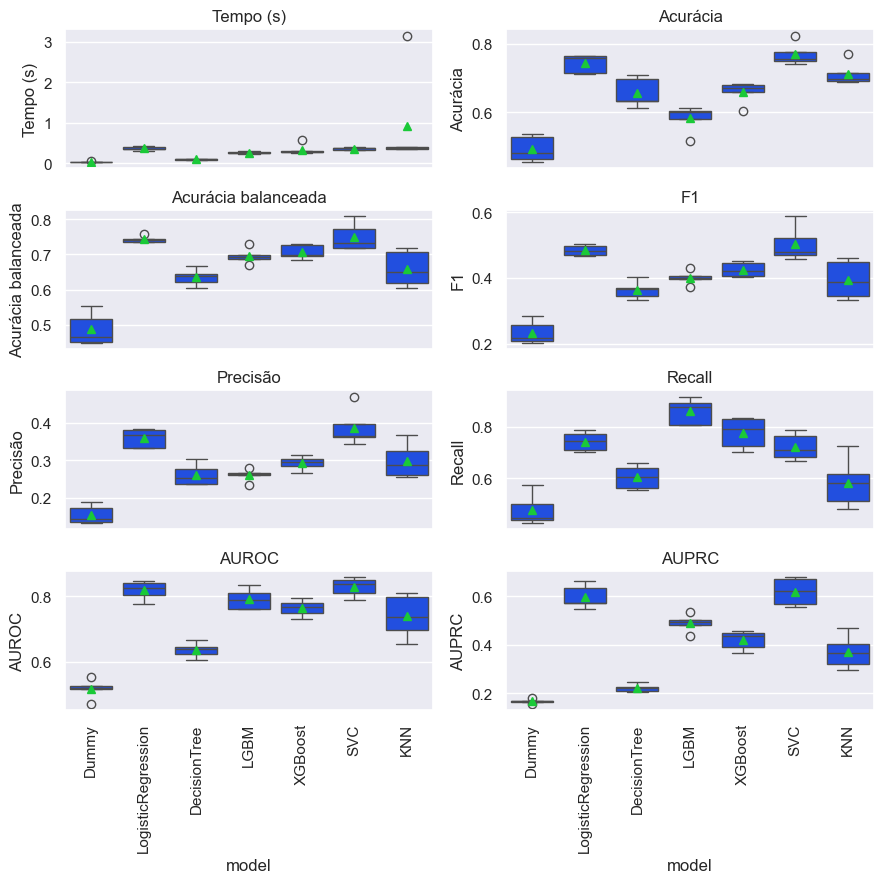

In [26]:
plot_comparar_metricas_modelos(df_resultados)

Logistic Regression e SVC apresentaram as melhores métricas de tempo e erro. 
Nesse caso seguiremos com o Logistic Regression devido aos critérios abaixo:
- Menor tempo de treinamento
- Melhor performance para os casos positivos de Desligamento (Recall)
- Mais fácil de interpretar e explicar o modelo


In [27]:
# param grid para LogisticRegression
param_grid = {
    "clf__C": [0.2, 0.3, 0.4],
    "clf__l1_ratio": [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
}


In [28]:
clf = LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', solver ='saga', max_iter=10000)

grid_search = grid_search_cv_classificador(
    clf, param_grid, kf, preprocessor_modelos, refit_metric="f1"
)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.2, 0.3, ...], 'clf__l1_ratio': [0.4, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [29]:
grid_search.fit(X, y)

Fitting 5 folds for each of 21 candidates, totalling 105 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.2, 0.3, ...], 'clf__l1_ratio': [0.4, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [30]:
grid_search.best_params_

{'clf__C': 0.2, 'clf__l1_ratio': 0.4}

In [31]:
grid_search.best_score_

np.float64(0.4962821712108754)

In [32]:
grid_search.best_estimator_

,steps,"[('preprocessor', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinal', ...), ('ordinal_viagem', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string rea

In [33]:
#classification report do melhor modelo
y_pred = grid_search.best_estimator_.predict(X)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.76      0.84      1233
           1       0.39      0.80      0.52       237

    accuracy                           0.76      1470
   macro avg       0.67      0.78      0.68      1470
weighted avg       0.86      0.76      0.79      1470



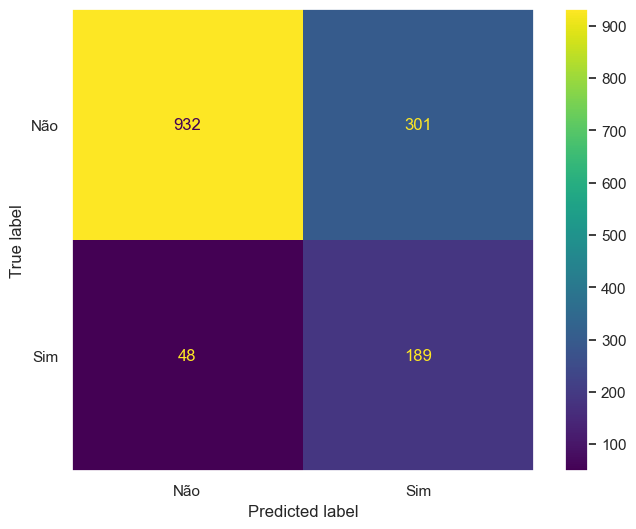

In [34]:
#Matriz de confusão
fig,ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X, y, display_labels=le.classes_, ax=ax)
plt.grid(False)
plt.show()

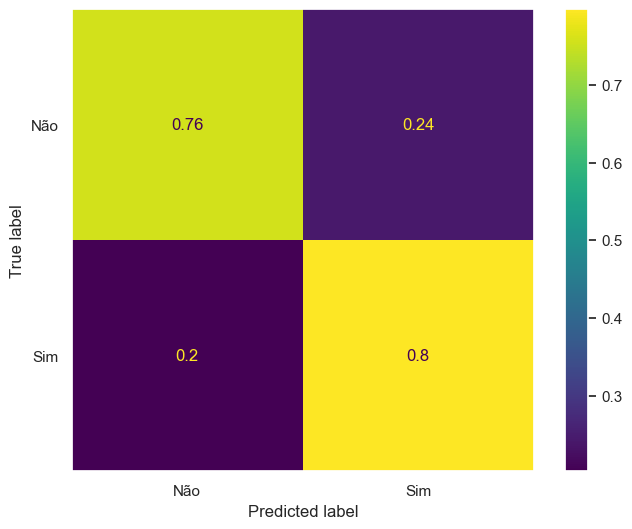

In [35]:
#Matriz de confusão
fig,ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X, y, display_labels=le.classes_, ax=ax, normalize="true")
plt.grid(False)
plt.show()

In [36]:
coefs = grid_search.best_estimator_.named_steps['clf'].coef_[0]
colunas = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

df_coefs = dataframe_coeficientes(coefs, colunas)
df_coefs.index = [s.split('__', 1)[-1] if isinstance(s, str) else s for s in df_coefs.index]
df_coefs.sort_values(by='coeficiente', ascending=False)

,coeficiente
HoraExtra_Sim,1.196389
ViagemDeNegocios,0.573767
Departamento_Vendas,0.535037
EstadoCivil_Solteiro(a),0.517932
Cargo_Técnico de Laboratório,0.376195
NumeroDeEmpresasQueTrabalhou,0.362602
Genero_Masculino,0.341174
AreaDeFormacao_Marketing,0.262505
Cargo_Representante de Vendas,0.250740
AreaDeFormacao_Curso Técnico,0.212053


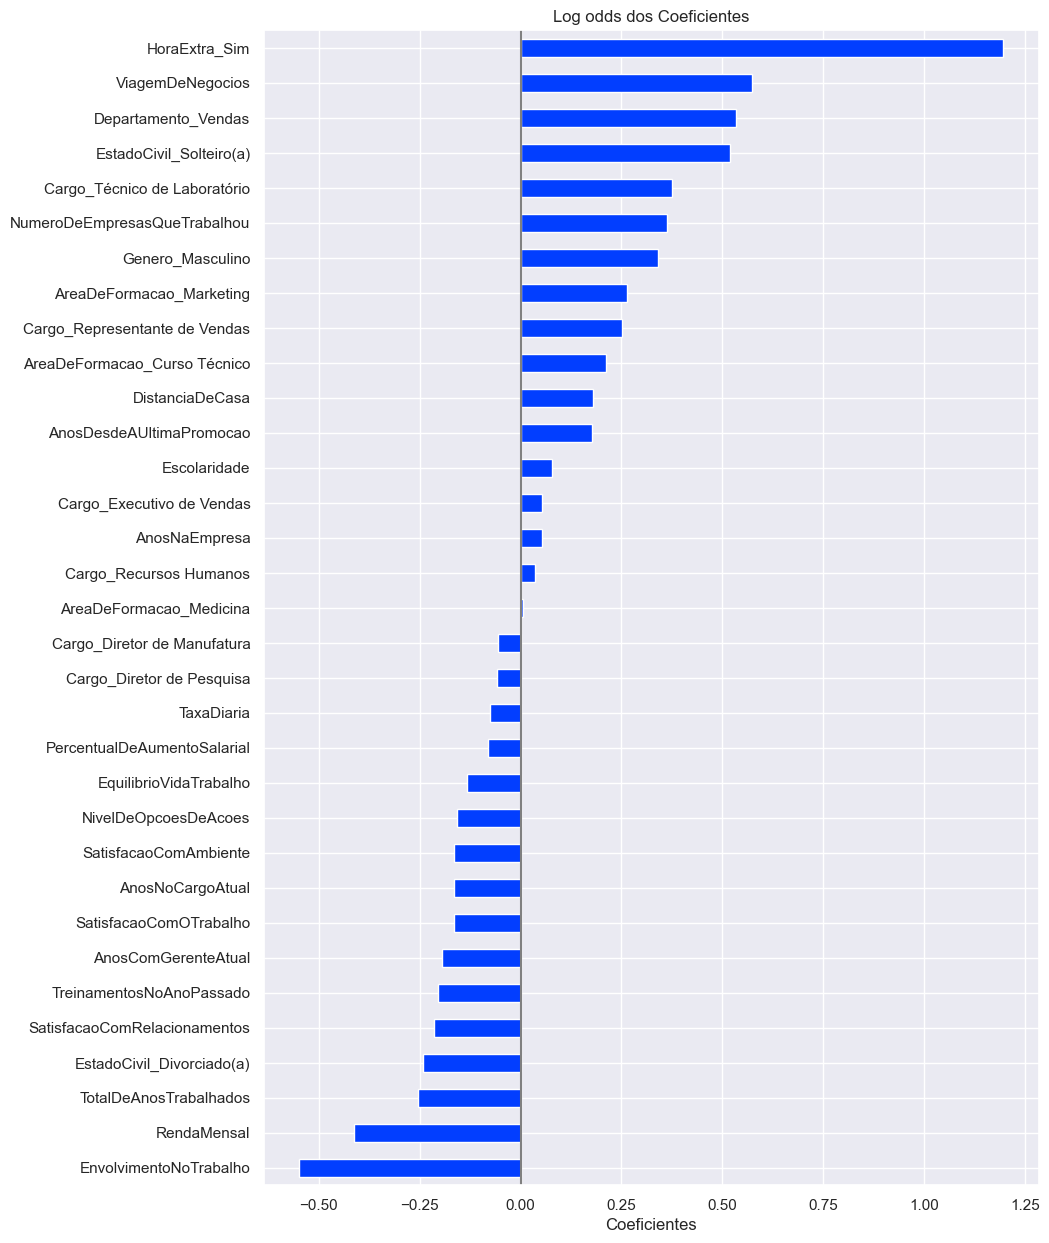

In [37]:
plot_coeficientes(df_coefs[df_coefs['coeficiente'] != 0], "Log odds dos Coeficientes")

In [38]:
#Odds ratio
df_coefs['odds_ratio'] = np.exp(df_coefs['coeficiente'])
df_coefs.sort_values(by='odds_ratio', ascending=False)

,coeficiente,odds_ratio
HoraExtra_Sim,1.196389,3.308148
ViagemDeNegocios,0.573767,1.774941
Departamento_Vendas,0.535037,1.707511
EstadoCivil_Solteiro(a),0.517932,1.678553
Cargo_Técnico de Laboratório,0.376195,1.456731
NumeroDeEmpresasQueTrabalhou,0.362602,1.437064
Genero_Masculino,0.341174,1.406597
AreaDeFormacao_Marketing,0.262505,1.300183
Cargo_Representante de Vendas,0.250740,1.284976
AreaDeFormacao_Curso Técnico,0.212053,1.236213


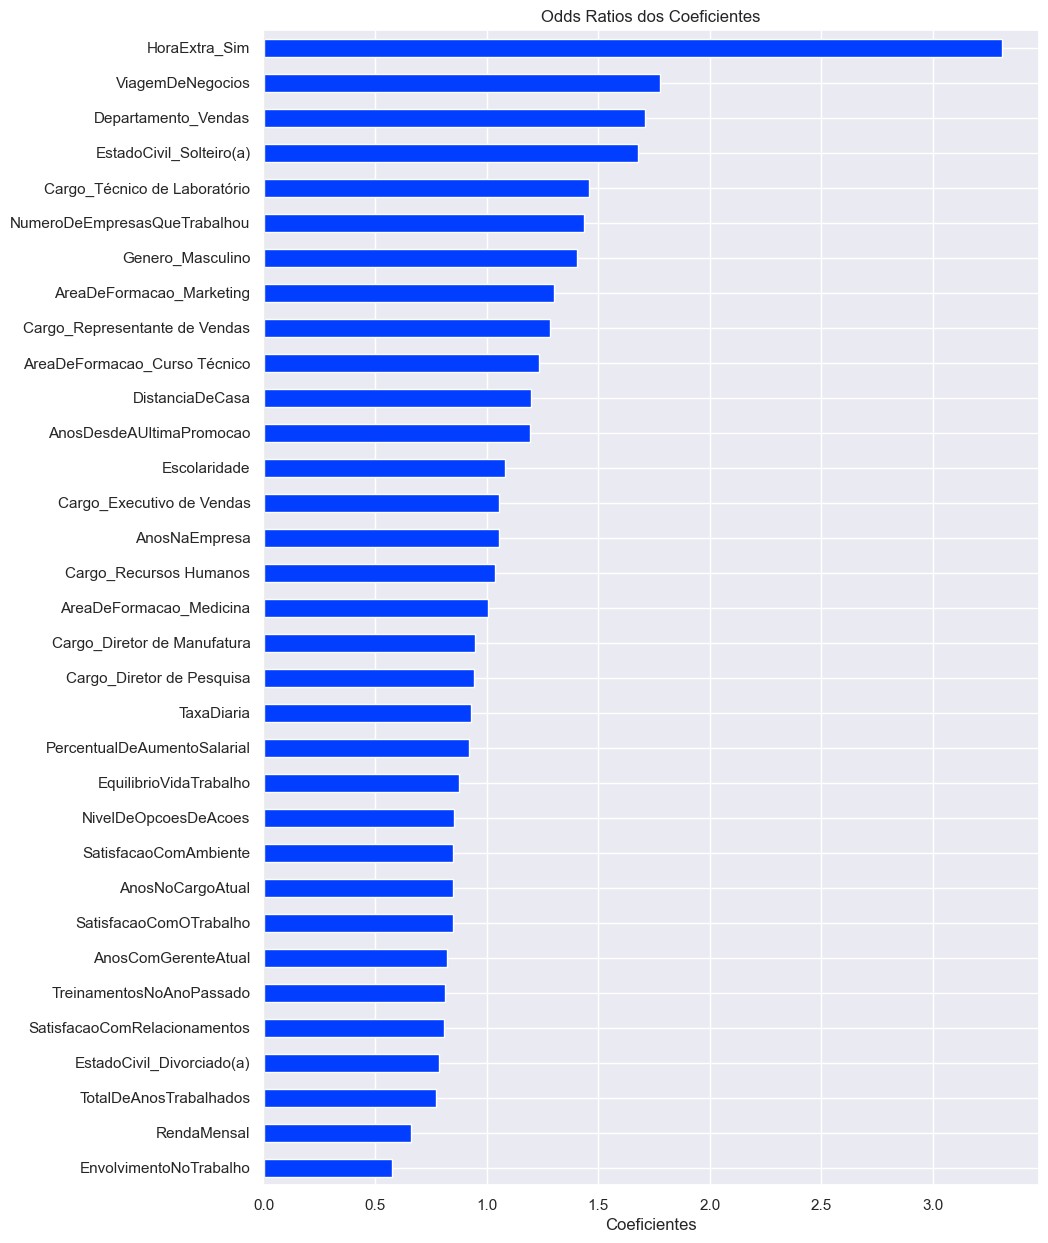

In [39]:
plot_coeficientes(df_coefs[[ "odds_ratio" ]][df_coefs['odds_ratio'] != 1], "Odds Ratios dos Coeficientes")

Insights da importância das variáveis:
- Quem faz hora extra e viaja a negócios tem maior probabilidade de desligamento
- Pessoas solteiras tem maior porbabilidade de desligamento em relação a casados e divorciados.
- Quem trabalha no departamento de vendas tem maior probabilidade de desligamento.
- Quanto maior a renda, menor a probabilidade de desligamento.

Plano de Ação:

Horas extras:
- Controle de Horas extras limitando a quantidade de horas extras por dia.
- Verificar a possibilidade de aplicação de automações em processos que exigem horas extras com frequencia.

Viagem de Negócios:
- Verificar a real necessidade de viagens, para que só ocorra quando for essencial.

Renda:
- Análisar se salário da empresa está compatível com o Mercado.

Vendas:
- Aplicar recompensas para quem atinge metas de tempo de casa para o Departamento de Vendas.


In [40]:
grid_search.best_estimator_

,steps,"[('preprocessor', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinal', ...), ('ordinal_viagem', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string rea

In [45]:
#salvar modelo
joblib.dump(grid_search.best_estimator_, MODELO_FINAL)

['C:\\Users\\gabri\\OneDrive\\Projetos_Analise_Dados\\IBM_Attrition\\modelos\\logistic_regression_rus.joblib']